<a href="https://colab.research.google.com/github/wngstnr-code/Traffic_Volume_Prediction_WeightedKNN/blob/main/ML_Regression_WeightedKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Muhammad Farrel Al Ghazy - 24/540589/TK/60022

Wangsit Nursyahada - 24/545092/TK/60594

*   **Theme:** SDG 11 - Sustainable Cities and Communities
*   **Problem:** Predicting hourly traffic volume to optimize urban mobility and reduce congestion.
*   **Dataset Source:** [UCI Machine Learning Repository - Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

**Load Dataset**

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
metro_interstate_traffic_volume = fetch_ucirepo(id=492)

# data (as pandas dataframes)
X = metro_interstate_traffic_volume.data.features
y = metro_interstate_traffic_volume.data.targets

# metadata
print(metro_interstate_traffic_volume.metadata)

# variable information
print(metro_interstate_traffic_volume.variables)

display(X.head())
display(y.head())

{'uci_id': 492, 'name': 'Metro Interstate Traffic Volume', 'repository_url': 'https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume', 'data_url': 'https://archive.ics.uci.edu/static/public/492/data.csv', 'abstract': 'Hourly Minneapolis-St Paul, MN traffic volume for westbound I-94. Includes weather and holiday features from 2012-2018.', 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 48204, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['traffic_volume'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2019, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5X60B', 'creators': ['John Hogue'], 'intro_paper': None, 'additional_info': {'summary': 'Hourly Interstate 94 Westbound traffic volume for MN DoT ATR station 301, roughly midway between Minneapolis and St Paul, MN. Hourly weath

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00


,traffic_volume
0,5545
1,4516
2,4767
3,5026
4,4918


**Install Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Exploratory Data Analysis (EDA)**

1.   Deskripsi dan Pengecekan Kualitas Data (Data Profiling)
2.   Analisis Distribusi Target (Target Variable Distribution)
3.   Analisis Pola Waktu (Temporal Analysis)
4.   Analisis Dampak Cuaca (Meteorological Analysis)
5.   Analisis Korelasi (Correlation Analysis)

In [ ]:
# 1. Deskripsi dan Pengecekan Kualitas Data (Data Profiling)
print("Struktur Data (X)")
print(X.info())

print("\nPengecekan Missing Values")
missing_vals = X.isnull().sum()
print(missing_vals)

print("\nStatistik Deskriptif Numerik")
display(X.describe())

print("\nStatistik Deskriptif Kategorikal")
display(X.describe(include=['object']))


print("\nINSIGHT DATA PROFILING")
holiday_missing_pct = (X['holiday'].isnull().sum() / len(X)) * 100
print(f"* Kolom 'holiday' memiliki {holiday_missing_pct:.2f}% data kosong. Ini mengindikasikan sebagian besar hari adalah 'Typical Day'.")

zero_temp_count = (X['temp'] == 0).sum()
if zero_temp_count > 0:
    print(f"* Ditemukan {zero_temp_count} baris dengan suhu 0 Kelvin. Ini adalah anomali data (outlier).")

max_rain = X['rain_1h'].max()
if max_rain > 500:
    print(f"* Curah hujan maksimum ({max_rain} mm) sangat ekstrem dan tidak realistis, perlu pembersihan.")

print("* Fitur 'date_time' masih bertipe object; perlu dikonversi ke datetime untuk analisis pola waktu.")

Struktur Data (X)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 2.9+ MB
None

Pengecekan Missing Values
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
dtype: int64

Statistik Deskriptif Numerik


,temp,rain_1h,snow_1h,clouds_all
count,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231
std,13.338232,44.789133,0.008168,39.015750
min,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000
50%,282.450000,0.000000,0.000000,64.000000
75%,291.806000,0.000000,0.000000,90.000000
max,310.070000,9831.300000,0.510000,100.000000



Statistik Deskriptif Kategorikal


,holiday,weather_main,weather_description,date_time
count,61,48204,48204,48204
unique,11,11,38,40575
top,Labor Day,Clouds,sky is clear,2013-04-18 22:00:00
freq,7,15164,11665,6



INSIGHT DATA PROFILING
* Kolom 'holiday' memiliki 99.87% data kosong. Ini mengindikasikan sebagian besar hari adalah 'Typical Day'.
* Ditemukan 10 baris dengan suhu 0 Kelvin. Ini adalah anomali data (outlier).
* Curah hujan maksimum (9831.3 mm) sangat ekstrem dan tidak realistis, perlu pembersihan.
* Fitur 'date_time' masih bertipe object; perlu dikonversi ke datetime untuk analisis pola waktu.


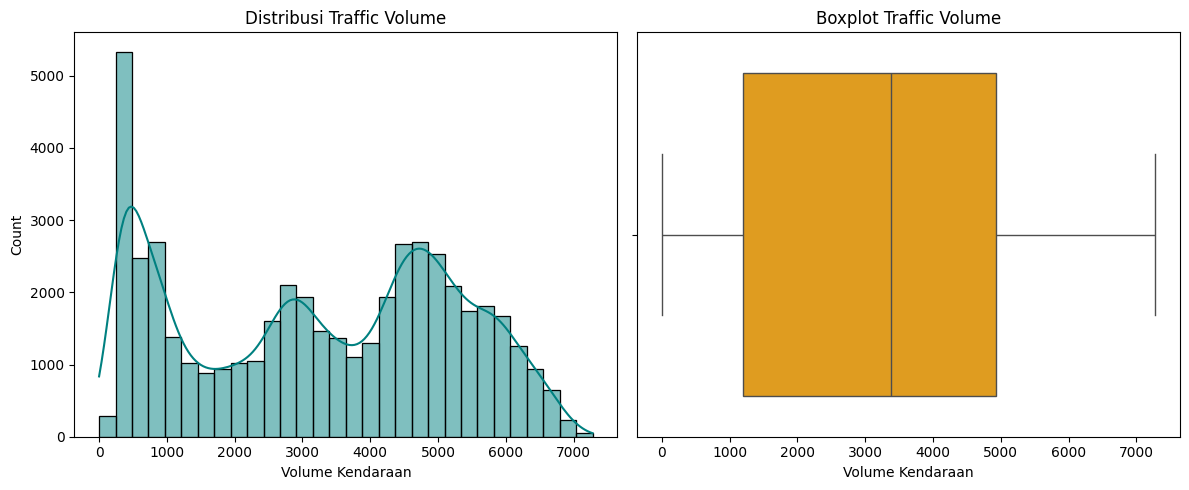

Statistik Deskriptif Target
count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

INSIGHT DISTRIBUSI TARGET
* Rata-rata volume kendaraan: 3260 unit per jam.
* Median (3380) lebih tinggi dari Mean (3260), menunjukkan sedikit skewness negatif.
* Distribusi terlihat bimodal (dua puncak), yang kemungkinan mewakili jam sibuk (peak hours) dan jam sepi (off-peak).
* Tidak ditemukan outlier ekstrem pada variabel target berdasarkan boxplot.


In [ ]:
# 2. Analisis Distribusi Target (Target Variable Distribution)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y['traffic_volume'], bins=30, kde=True, color='teal')
plt.title('Distribusi Traffic Volume')
plt.xlabel('Volume Kendaraan')

plt.subplot(1, 2, 2)
sns.boxplot(x=y['traffic_volume'], color='orange')
plt.title('Boxplot Traffic Volume')
plt.xlabel('Volume Kendaraan')

plt.tight_layout()
plt.show()

target_desc = y['traffic_volume'].describe()
print("Statistik Deskriptif Target")
print(target_desc)

print("\nINSIGHT DISTRIBUSI TARGET")
print(f"* Rata-rata volume kendaraan: {target_desc['mean']:.0f} unit per jam.")
print(f"* Median ({target_desc['50%']:.0f}) lebih tinggi dari Mean ({target_desc['mean']:.0f}), menunjukkan sedikit skewness negatif.")
print("* Distribusi terlihat bimodal (dua puncak), yang kemungkinan mewakili jam sibuk (peak hours) dan jam sepi (off-peak).")
print("* Tidak ditemukan outlier ekstrem pada variabel target berdasarkan boxplot.")

/tmp/ipykernel_1027/2020977669.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_df, x='day_of_week', y='traffic_volume', palette='viridis')


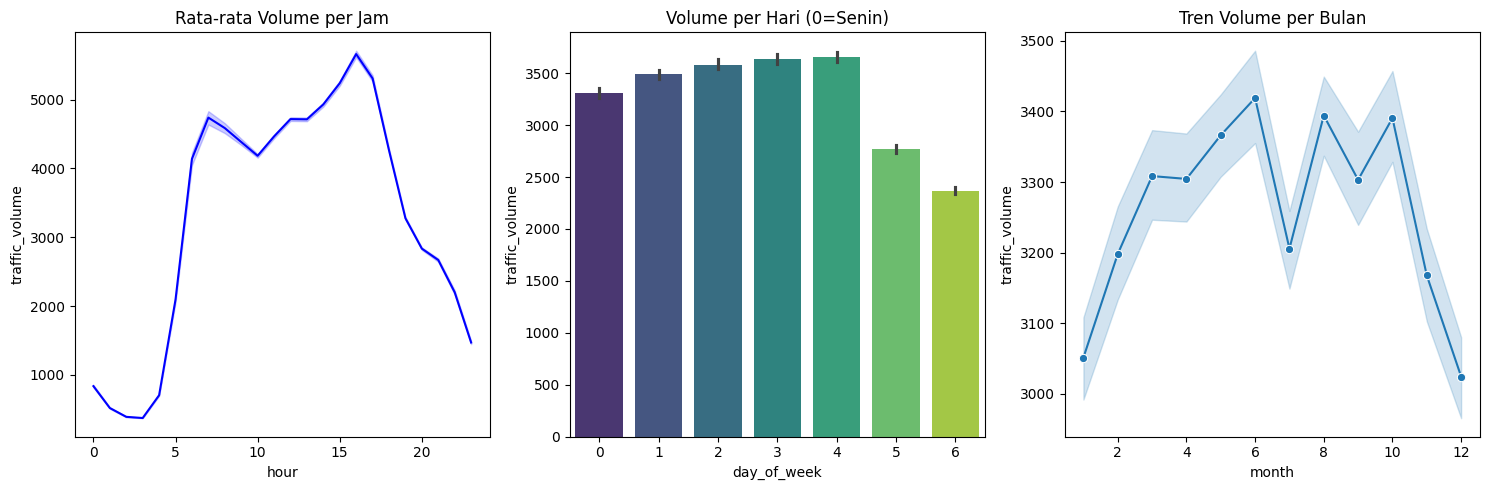

INSIGHT ANALISIS POLA WAKTU
* Pola Jam: Terlihat dua puncak utama (rush hour) sekitar jam 7-8 pagi dan jam 4-5 sore.
* Pola Hari: Volume lalu lintas jauh lebih rendah pada hari Sabtu (5) dan Minggu (6) dibandingkan hari kerja.
* Pola Bulanan: Terdapat fluktuasi musiman, di mana volume cenderung turun di bulan-bulan musim dingin (Januari/Desember).
* Kesimpulan: Fitur waktu adalah prediktor yang sangat kuat untuk volume lalu lintas.


In [ ]:
# 3. Analisis Pola Waktu (Temporal Analysis)
X_temp = X.copy()
X_temp['date_time'] = pd.to_datetime(X_temp['date_time'])

X_temp['hour'] = X_temp['date_time'].dt.hour
X_temp['day_of_week'] = X_temp['date_time'].dt.dayofweek
X_temp['month'] = X_temp['date_time'].dt.month

temp_df = pd.concat([X_temp, y], axis=1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.lineplot(data=temp_df, x='hour', y='traffic_volume', color='blue')
plt.title('Rata-rata Volume per Jam')

plt.subplot(1, 3, 2)
sns.barplot(data=temp_df, x='day_of_week', y='traffic_volume', palette='viridis')
plt.title('Volume per Hari (0=Senin)')

plt.subplot(1, 3, 3)
sns.lineplot(data=temp_df, x='month', y='traffic_volume', marker='o')
plt.title('Tren Volume per Bulan')

plt.tight_layout()
plt.show()

print("INSIGHT ANALISIS POLA WAKTU")
print("* Pola Jam: Terlihat dua puncak utama (rush hour) sekitar jam 7-8 pagi dan jam 4-5 sore.")
print("* Pola Hari: Volume lalu lintas jauh lebih rendah pada hari Sabtu (5) dan Minggu (6) dibandingkan hari kerja.")
print("* Pola Bulanan: Terdapat fluktuasi musiman, di mana volume cenderung turun di bulan-bulan musim dingin (Januari/Desember).")
print("* Kesimpulan: Fitur waktu adalah prediktor yang sangat kuat untuk volume lalu lintas.")

/tmp/ipykernel_1027/2169269065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_df, x='traffic_volume', y='weather_main', order=weather_order, palette='magma')


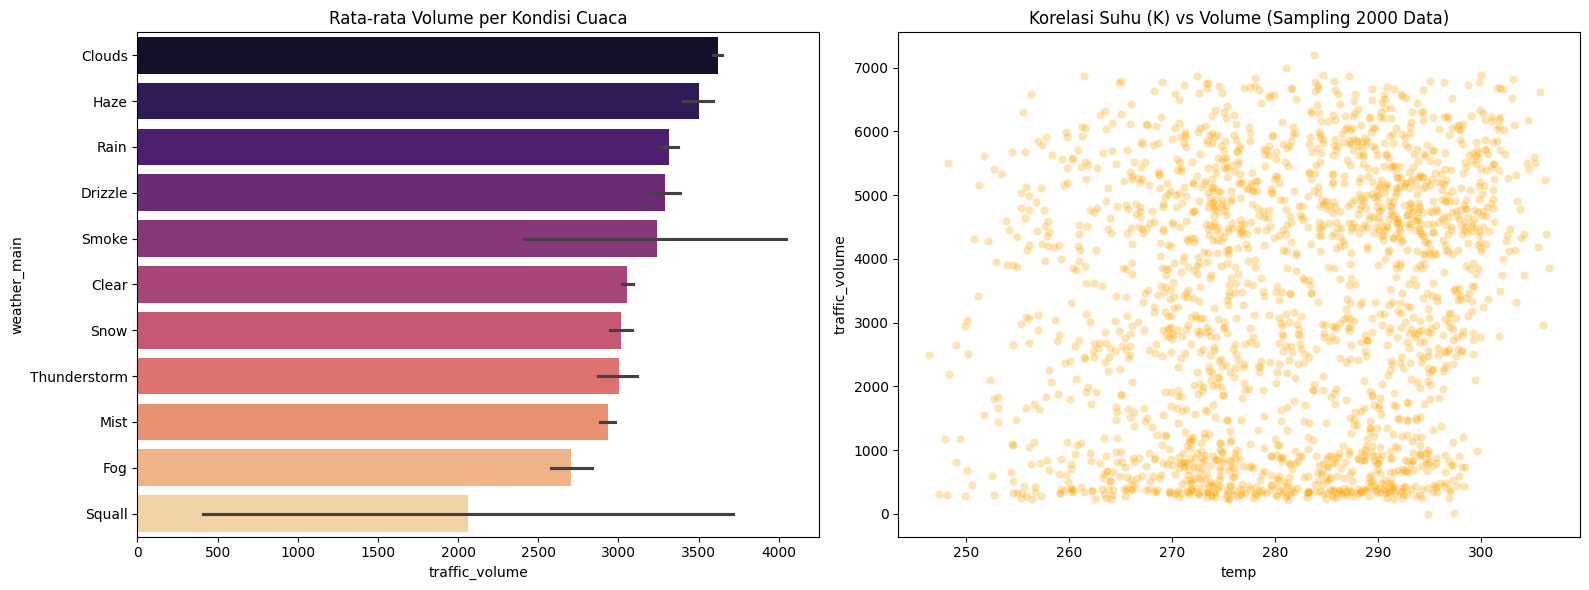

INSIGHT ANALISIS DAMPAK CUACA
* Kondisi Cuaca: Volume lalu lintas tetap tinggi saat 'Clouds' atau 'Clear'. Penurunan terlihat pada cuaca ekstrem seperti 'Squall'.
* Dampak Hujan/Salju: Meskipun ada hujan/salju, volume tidak turun drastis, menunjukkan komuter tetap bepergian kecuali kondisi sangat parah.
* Anomali Suhu: Terlihat titik-titik data di suhu 0 Kelvin yang tidak memiliki korelasi logis dengan volume; ini memperkuat kebutuhan pembersihan data.
* Kesimpulan: Faktor cuaca memiliki pengaruh, namun tidak sedominan faktor waktu (jam/hari).


In [ ]:
# 4. Analisis Dampak Cuaca (Meteorological Analysis)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
weather_order = temp_df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False).index
sns.barplot(data=temp_df, x='traffic_volume', y='weather_main', order=weather_order, palette='magma')
plt.title('Rata-rata Volume per Kondisi Cuaca')

plt.subplot(1, 2, 2)
sns.scatterplot(data=temp_df.sample(2000), x='temp', y='traffic_volume', alpha=0.3, color='orange')
plt.title('Korelasi Suhu (K) vs Volume (Sampling 2000 Data)')

plt.tight_layout()
plt.show()

print("INSIGHT ANALISIS DAMPAK CUACA")
print("* Kondisi Cuaca: Volume lalu lintas tetap tinggi saat 'Clouds' atau 'Clear'. Penurunan terlihat pada cuaca ekstrem seperti 'Squall'.")
print("* Dampak Hujan/Salju: Meskipun ada hujan/salju, volume tidak turun drastis, menunjukkan komuter tetap bepergian kecuali kondisi sangat parah.")
print("* Anomali Suhu: Terlihat titik-titik data di suhu 0 Kelvin yang tidak memiliki korelasi logis dengan volume; ini memperkuat kebutuhan pembersihan data.")
print("* Kesimpulan: Faktor cuaca memiliki pengaruh, namun tidak sedominan faktor waktu (jam/hari).")

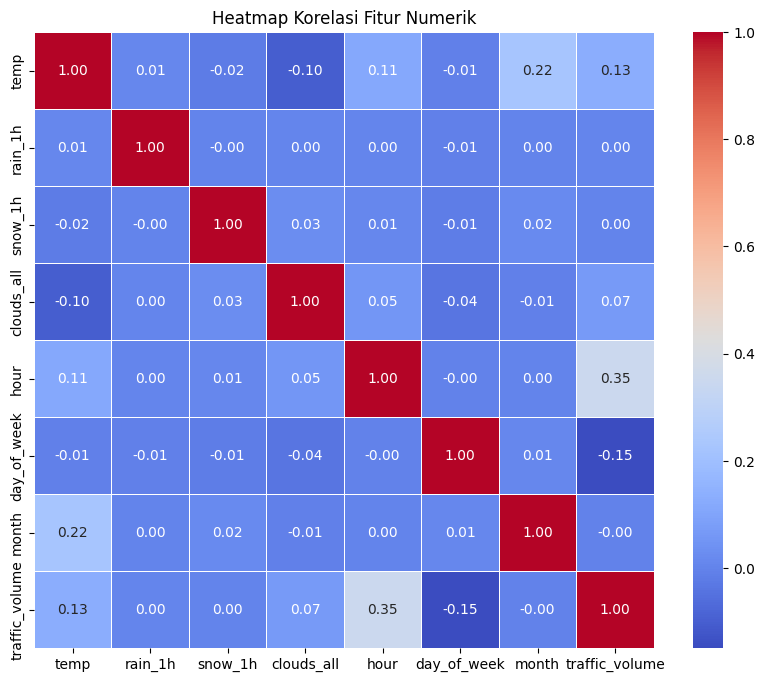

INSIGHT ANALISIS KORELASI
* Korelasi Tertinggi: Fitur 'hour' memiliki korelasi positif terkuat (0.35) dengan traffic_volume.
* Korelasi Cuaca: Fitur cuaca seperti 'temp' (0.13) dan 'clouds_all' memiliki korelasi yang sangat lemah terhadap volume.
* Multikolinearitas: Tidak terlihat adanya korelasi yang sangat tinggi ( > 0.8) antar fitur independen, sehingga risiko redundansi fitur rendah.
* Kesimpulan Akhir EDA: Fokus utama pemodelan harus pada fitur temporal (Waktu), dibantu dengan pembersihan outlier pada fitur cuaca.


In [ ]:
# 5. Analisis Korelasi (Correlation Analysis)
plt.figure(figsize=(10, 8))

corr_matrix = temp_df[['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'traffic_volume']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

print("INSIGHT ANALISIS KORELASI")
print(f"* Korelasi Tertinggi: Fitur 'hour' memiliki korelasi positif terkuat ({corr_matrix['traffic_volume']['hour']:.2f}) dengan traffic_volume.")
print(f"* Korelasi Cuaca: Fitur cuaca seperti 'temp' ({corr_matrix['traffic_volume']['temp']:.2f}) dan 'clouds_all' memiliki korelasi yang sangat lemah terhadap volume.")
print("* Multikolinearitas: Tidak terlihat adanya korelasi yang sangat tinggi ( > 0.8) antar fitur independen, sehingga risiko redundansi fitur rendah.")
print("* Kesimpulan Akhir EDA: Fokus utama pemodelan harus pada fitur temporal (Waktu), dibantu dengan pembersihan outlier pada fitur cuaca.")

**Data Preprocessing**

1.   Ekstraksi Fitur Waktu (Temporal Feature Extraction)
2.   Pembersihan Anomali Logika (Data Cleansing)
3.   Transformasi Data Kategorikal (Encoding)
4.   Standarisasi Skala Fitur (Feature Scaling)
5.   Pemisahan Data Latih dan Uji (Manual Train-Test Split)

In [ ]:
# 1. Ekstraksi Fitur Waktu (Temporal Feature Extraction)
X_preprocessed = X.copy()

X_preprocessed['date_time'] = pd.to_datetime(X_preprocessed['date_time'])

X_preprocessed['hour'] = X_preprocessed['date_time'].dt.hour
X_preprocessed['day_of_week'] = X_preprocessed['date_time'].dt.dayofweek
X_preprocessed['month'] = X_preprocessed['date_time'].dt.month

X_preprocessed = X_preprocessed.drop('date_time', axis=1)

display(X_preprocessed[['hour', 'day_of_week', 'month']].head())

print("\nINSIGHT EKSTRAKSI FITUR WAKTU")
print("* Fitur 'hour' (0-23): Akan menangkap pola jam sibuk (rush hour) pagi dan sore.")
print("* Fitur 'day_of_week' (0=Senin, 6=Minggu): Memungkinkan model membedakan pola hari kerja vs akhir pekan.")
print("* Fitur 'month' (1-12): Membantu model mengidentifikasi variasi musiman lalu lintas.")
print("* Kolom 'date_time' asli telah dihapus karena informasinya sudah diekstrak ke fitur numerik.")

,hour,day_of_week,month
0,9,1,10
1,10,1,10
2,11,1,10
3,12,1,10
4,13,1,10



INSIGHT EKSTRAKSI FITUR WAKTU
* Fitur 'hour' (0-23): Akan menangkap pola jam sibuk (rush hour) pagi dan sore.
* Fitur 'day_of_week' (0=Senin, 6=Minggu): Memungkinkan model membedakan pola hari kerja vs akhir pekan.
* Fitur 'month' (1-12): Membantu model mengidentifikasi variasi musiman lalu lintas.
* Kolom 'date_time' asli telah dihapus karena informasinya sudah diekstrak ke fitur numerik.


In [ ]:
# 2. Pembersihan Anomali Logika (Data Cleansing)
mean_temp = X_preprocessed[X_preprocessed['temp'] > 0]['temp'].mean()
X_preprocessed['temp'] = X_preprocessed['temp'].replace(0, mean_temp)

max_reasonable_rain = 100
X_preprocessed.loc[X_preprocessed['rain_1h'] > max_reasonable_rain, 'rain_1h'] = max_reasonable_rain

X_preprocessed['holiday'] = X_preprocessed['holiday'].fillna('None')

display(X_preprocessed.head())

print("HASIL PEMBERSIHAN")
print(f"Jumlah suhu 0 K setelah pembersihan: {(X_preprocessed['temp'] == 0).sum()}")
print(f"Curah hujan maksimum: {X_preprocessed['rain_1h'].max()} mm")
print(f"Jumlah missing values di 'holiday': {X_preprocessed['holiday'].isnull().sum()}")

print("\nINSIGHT PEMBERSIHAN DATA")
print("* Imputasi Suhu: Nilai 0 K diganti dengan rata-rata (~281 K).")
print("* Clipping Curah Hujan: Nilai ekstrem dipangkas menjadi 100 mm.")
print("* Labeling Holiday: Baris kosong kini memiliki label 'None'.")

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,hour,day_of_week,month
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,9,1,10
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,10,1,10
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,11,1,10
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,12,1,10
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,13,1,10


HASIL PEMBERSIHAN
Jumlah suhu 0 K setelah pembersihan: 0
Curah hujan maksimum: 100.0 mm
Jumlah missing values di 'holiday': 0

INSIGHT PEMBERSIHAN DATA
* Imputasi Suhu: Nilai 0 K diganti dengan rata-rata (~281 K).
* Clipping Curah Hujan: Nilai ekstrem dipangkas menjadi 100 mm.
* Labeling Holiday: Baris kosong kini memiliki label 'None'.


In [ ]:
# 3. Transformasi Data Kategorikal (Encoding)
import pandas as pd

X_encoded = pd.get_dummies(X_preprocessed, columns=['holiday', 'weather_main', 'weather_description'], prefix=['hld', 'wtr', 'desc'])

display(X_encoded.head())

print("HASIL ENCODING")
print(f"Jumlah kolom sebelum encoding: {X_preprocessed.shape[1]}")
print(f"Jumlah kolom setelah encoding: {X_encoded.shape[1]}")

print("\nINSIGHT TRANSFORMASI KATEGORIKAL")
print("* One-Hot Encoding: Kita mengubah data kategori menjadi kolom biner (0 atau 1). Ini penting untuk KNN karena KNN tidak bisa menghitung 'jarak' antara kata-kata.")
print(f"* Ekspansi Fitur: Data berkembang menjadi {X_encoded.shape[1]} kolom karena setiap jenis cuaca dan hari libur kini menjadi fitur independen.")
print("* Kesiapan Model: Dengan semua data dalam bentuk numerik, dataset kini secara teknis siap untuk dihitung jaraknya (Euclidean Distance).")

,temp,rain_1h,snow_1h,clouds_all,hour,day_of_week,month,hld_Christmas Day,hld_Columbus Day,hld_Independence Day,...,desc_sleet,desc_smoke,desc_snow,desc_thunderstorm,desc_thunderstorm with drizzle,desc_thunderstorm with heavy rain,desc_thunderstorm with light drizzle,desc_thunderstorm with light rain,desc_thunderstorm with rain,desc_very heavy rain
0,288.28,0.0,0.0,40,9,1,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,10,1,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,11,1,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,12,1,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,13,1,10,False,False,False,...,False,False,False,False,False,False,False,False,False,False


HASIL ENCODING
Jumlah kolom sebelum encoding: 10
Jumlah kolom setelah encoding: 68

INSIGHT TRANSFORMASI KATEGORIKAL
* One-Hot Encoding: Kita mengubah data kategori menjadi kolom biner (0 atau 1). Ini penting untuk KNN karena KNN tidak bisa menghitung 'jarak' antara kata-kata.
* Ekspansi Fitur: Data berkembang menjadi 68 kolom karena setiap jenis cuaca dan hari libur kini menjadi fitur independen.
* Kesiapan Model: Dengan semua data dalam bentuk numerik, dataset kini secara teknis siap untuk dihitung jaraknya (Euclidean Distance).


In [ ]:
# 4. Standarisasi Skala Fitur (Feature Scaling) - Manual Standardization (Z-score)
X_mean = X_encoded.mean()
X_std = X_encoded.std()

X_scaled = (X_encoded - X_mean) / X_std

X_scaled = X_scaled.fillna(0)

display(X_scaled.head())

print("HASIL STANDARISASI")
print(f"Mean fitur pertama setelah scaling: {X_scaled.iloc[:, 0].mean():.2f}")
print(f"Std fitur pertama setelah scaling: {X_scaled.iloc[:, 0].std():.2f}")

print("\nINSIGHT STANDARISASI FITUR")
print("* Adil untuk Semua Fitur: Tanpa scaling, 'temp' (~280) akan dianggap 280x lebih penting daripada 'rain_1h' jika nilainya 1. Setelah scaling, keduanya memiliki bobot yang setara.")
print("* Optimal untuk KNN: KNN mencari tetangga terdekat berdasarkan Jarak Euclidean. Standarisasi memastikan jarak dihitung dalam ruang dimensi yang proporsional.")
print("* Z-Score: Semua fitur kini memiliki rata-rata 0 dan standar deviasi 1.")

,temp,rain_1h,snow_1h,clouds_all,hour,day_of_week,month,hld_Christmas Day,hld_Columbus Day,hld_Independence Day,...,desc_sleet,desc_smoke,desc_snow,desc_thunderstorm,desc_thunderstorm with drizzle,desc_thunderstorm with heavy rain,desc_thunderstorm with light drizzle,desc_thunderstorm with light rain,desc_thunderstorm with rain,desc_very heavy rain
0,0.552064,-0.12017,-0.027228,-0.239960,-0.345545,-0.989551,1.027569,-0.011157,-0.010185,-0.010185,...,-0.007889,-0.020373,-0.078201,-0.050989,-0.006441,-0.036175,-0.017643,-0.033488,-0.027715,-0.019327
1,0.637048,-0.12017,-0.027228,0.657113,-0.201457,-0.989551,1.027569,-0.011157,-0.010185,-0.010185,...,-0.007889,-0.020373,-0.078201,-0.050989,-0.006441,-0.036175,-0.017643,-0.033488,-0.027715,-0.019327
2,0.654360,-0.12017,-0.027228,1.041573,-0.057370,-0.989551,1.027569,-0.011157,-0.010185,-0.010185,...,-0.007889,-0.020373,-0.078201,-0.050989,-0.006441,-0.036175,-0.017643,-0.033488,-0.027715,-0.019327
3,0.697639,-0.12017,-0.027228,1.041573,0.086717,-0.989551,1.027569,-0.011157,-0.010185,-0.010185,...,-0.007889,-0.020373,-0.078201,-0.050989,-0.006441,-0.036175,-0.017643,-0.033488,-0.027715,-0.019327
4,0.777115,-0.12017,-0.027228,0.657113,0.230804,-0.989551,1.027569,-0.011157,-0.010185,-0.010185,...,-0.007889,-0.020373,-0.078201,-0.050989,-0.006441,-0.036175,-0.017643,-0.033488,-0.027715,-0.019327


HASIL STANDARISASI
Mean fitur pertama setelah scaling: -0.00
Std fitur pertama setelah scaling: 1.00

INSIGHT STANDARISASI FITUR
* Adil untuk Semua Fitur: Tanpa scaling, 'temp' (~280) akan dianggap 280x lebih penting daripada 'rain_1h' jika nilainya 1. Setelah scaling, keduanya memiliki bobot yang setara.
* Optimal untuk KNN: KNN mencari tetangga terdekat berdasarkan Jarak Euclidean. Standarisasi memastikan jarak dihitung dalam ruang dimensi yang proporsional.
* Z-Score: Semua fitur kini memiliki rata-rata 0 dan standar deviasi 1.


In [ ]:
# 5. Pemisahan Data Latih dan Uji (80:20)
train_ratio = 0.8
train_size = int(len(X_scaled) * train_ratio)

np.random.seed(42)
indices = np.random.permutation(len(X_scaled))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X_scaled.iloc[train_idx].values
X_test = X_scaled.iloc[test_idx].values
y_train = y.iloc[train_idx].values.flatten()
y_test = y.iloc[test_idx].values.flatten()

print("HASIL PEMISAHAN DATA")
print(f"Jumlah Data Latih (X_train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (X_test): {X_test.shape[0]} baris")

print("\nINSIGHT")
print(f"* Pembagian ke rasio 80:20 untuk menjaga validitas evaluasi statistik.")

HASIL PEMISAHAN DATA
Jumlah Data Latih (X_train): 38563 baris
Jumlah Data Uji (X_test): 9641 baris

INSIGHT
* Pembagian ke rasio 80:20 untuk menjaga validitas evaluasi statistik.


**Pembangunan Model Weighted K-Nearest Neighbors (Weighted KNN) Regressor**

1.   Penentuan Metrik Kemiripan (Distance Calculation)
2.   Penentuan Parameter 'K' (Hyperparameter Initialization)
3.   Pencarian Tetangga Terdekat (Sorting & Filtering)
4.   Kalkulasi Prediksi Akhir (Inverse Distance Weighting)

In [ ]:
# 1. Penentuan Metrik Kemiripan (Distance Calculation) - Manual Euclidean Distance
def calculate_euclidean_distance(point_a, point_b):

    squared_diff = (point_a - point_b) ** 2

    distance = np.sqrt(np.sum(squared_diff))
    return distance

sample_dist = calculate_euclidean_distance(X_train[0], X_train[1])

print("HASIL PERHITUNGAN JARAK")
print(f"Jarak antara data ke-0 dan ke-1: {sample_dist:.4f}")

print("\nINSIGHT METRIK KEMIRIPAN")
print("* Jarak Euclidean: Ini adalah metrik paling umum untuk KNN. Semakin kecil nilainya, semakin 'mirip' atau 'dekat' karakteristik cuaca/waktu antar dua titik data.")
print("* Peran Standarisasi: Berkat standarisasi yang kita lakukan sebelumnya, perhitungan jarak ini sekarang bersifat adil (tidak didominasi oleh satu fitur tertentu).")
print("* Kompleksitas: Karena kita memiliki 68 fitur, jarak ini dihitung dalam ruang 68-dimensi (Hyper-space).")

HASIL PERHITUNGAN JARAK
Jarak antara data ke-0 dan ke-1: 11.2979

INSIGHT METRIK KEMIRIPAN
* Jarak Euclidean: Ini adalah metrik paling umum untuk KNN. Semakin kecil nilainya, semakin 'mirip' atau 'dekat' karakteristik cuaca/waktu antar dua titik data.
* Peran Standarisasi: Berkat standarisasi yang kita lakukan sebelumnya, perhitungan jarak ini sekarang bersifat adil (tidak didominasi oleh satu fitur tertentu).
* Kompleksitas: Karena kita memiliki 68 fitur, jarak ini dihitung dalam ruang 68-dimensi (Hyper-space).


MEMULAI TUNING PARAMETER K (Menguji 8 kombinasi)
K = 1 | Mean Absolute Error: 579.02
K = 3 | Mean Absolute Error: 490.47
K = 5 | Mean Absolute Error: 547.44
K = 7 | Mean Absolute Error: 552.91
K = 9 | Mean Absolute Error: 554.26
K = 11 | Mean Absolute Error: 582.14
K = 13 | Mean Absolute Error: 631.51
K = 15 | Mean Absolute Error: 648.87


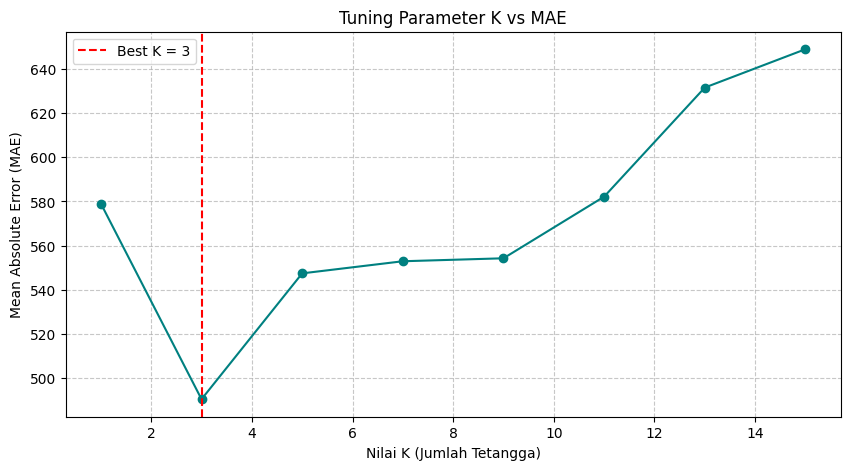

INISIALISASI PARAMETER
Jumlah tetangga terdekat (K) yang digunakan: 3

INSIGHT
* Berdasarkan tahap tuning, K=3 terbukti memberikan error (MAE) paling rendah.


In [ ]:
# 2. Penentuan Parameter 'K' (Hyperparameter Initialization)
def get_neighbors(X_train, y_train, test_row, k):
    distances = []
    for i in range(len(X_train)):
        dist = calculate_euclidean_distance(test_row, X_train[i])
        distances.append((y_train[i], dist))

    distances.sort(key=lambda x: x[1])

    return [distances[i][0] for i in range(k)]

def calculate_prediction(neighbors):
    return sum(neighbors) / len(neighbors)

k_candidates = [1, 3, 5, 7, 9, 11, 13, 15]
mae_results = []
n_tuning_samples = 50

print(f"MEMULAI TUNING PARAMETER K (Menguji {len(k_candidates)} kombinasi)")

for k_val in k_candidates:
    fold_errors = []
    for i in range(n_tuning_samples):
        neighbors = get_neighbors(X_train, y_train, X_test[i], k_val)
        pred = calculate_prediction(neighbors)
        fold_errors.append(abs(pred - y_test[i]))

    avg_mae = sum(fold_errors) / len(fold_errors)
    mae_results.append(avg_mae)
    print(f"K = {k_val} | Mean Absolute Error: {avg_mae:.2f}")

best_k_index = np.argmin(mae_results)
best_k = k_candidates[best_k_index]

plt.figure(figsize=(10, 5))
plt.plot(k_candidates, mae_results, marker='o', linestyle='-', color='teal')
plt.title('Tuning Parameter K vs MAE')
plt.xlabel('Nilai K (Jumlah Tetangga)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()

print(f"INISIALISASI PARAMETER")
print(f"Jumlah tetangga terdekat (K) yang digunakan: {best_k}")

print("\nINSIGHT")
print(f"* Berdasarkan tahap tuning, K={best_k} terbukti memberikan error (MAE) paling rendah.")

In [ ]:
# 3. Pencarian Tetangga Terdekat (Sorting & Filtering)
def get_neighbors(X_train, y_train, test_point, k):

    distances = np.sqrt(np.sum((X_train - test_point)**2, axis=1))

    neighbor_data = []
    for i in range(len(distances)):
        neighbor_data.append([distances[i], y_train[i]])

    neighbor_data.sort(key=lambda x: x[0])

    nearest_neighbors = neighbor_data[:k]

    return nearest_neighbors

sample_neighbors = get_neighbors(X_train, y_train, X_test[0], best_k)

print(f"HASIL PENCARIAN {best_k} TETANGGA TERDEKAT")
for i, neighbor in enumerate(sample_neighbors):
    print(f"Tetangga ke-{i+1}: Jarak = {neighbor[0]:.4f}, Traffic Volume = {neighbor[1]}")

print("\nINSIGHT PENCARIAN TETANGGA")
print("* Komputasi: Untuk setiap 1 data uji, model harus membandingkan dirinya dengan seluruh data latih. Ini adalah alasan mengapa KNN disebut sebagai 'Lazy Learner'.")
print("* Sorting: Jarak terkecil menunjukkan tingkat kemiripan tertinggi.")
print(f"* Filtering: Dengan membatasi hanya pada K={best_k}, kita mengabaikan ribuan data lain yang karakteristiknya terlalu berbeda.")

HASIL PENCARIAN 3 TETANGGA TERDEKAT
Tetangga ke-1: Jarak = 0.0866, Traffic Volume = 4910
Tetangga ke-2: Jarak = 0.0921, Traffic Volume = 4348
Tetangga ke-3: Jarak = 0.1444, Traffic Volume = 4790

INSIGHT PENCARIAN TETANGGA
* Komputasi: Untuk setiap 1 data uji, model harus membandingkan dirinya dengan seluruh data latih. Ini adalah alasan mengapa KNN disebut sebagai 'Lazy Learner'.
* Sorting: Jarak terkecil menunjukkan tingkat kemiripan tertinggi.
* Filtering: Dengan membatasi hanya pada K=3, kita mengabaikan ribuan data lain yang karakteristiknya terlalu berbeda.


In [ ]:
# 4. Kalkulasi Prediksi Akhir (Inverse Distance Weighting)
def calculate_prediction(neighbors):
    epsilon = 1e-5

    weights = [1.0 / (n[0] + epsilon) for n in neighbors]
    weighted_volumes = [neighbors[i][1] * weights[i] for i in range(len(neighbors))]

    return sum(weighted_volumes) / sum(weights)

sample_neighbors = get_neighbors(X_train, y_train, X_test[0], best_k)
final_prediction = calculate_prediction(sample_neighbors)
actual_value = y_test[0]

print(f"HASIL PREDIKSI AKHIR (DENGAN WEIGHTING)")
print(f"Volume Prediksi : {final_prediction:.2f} kendaraan")
print(f"Volume Aktual   : {actual_value:.2f} kendaraan")
print(f"Selisih (Error) : {abs(final_prediction - actual_value):.2f} kendaraan")

HASIL PREDIKSI AKHIR (DENGAN WEIGHTING)
Volume Prediksi : 4673.61 kendaraan
Volume Aktual   : 4763.00 kendaraan
Selisih (Error) : 89.39 kendaraan


**Result Validation (K-Fold Cross-Validation)**



In [ ]:
# K-Fold Cross-Validation (K=5)
k_folds = 5
fold_size = len(X_train) // k_folds
fold_maes = []
fold_mses = []

print(f"Memulai {k_folds}-Fold Cross Validation pada data latih...")

for fold in range(k_folds):
    start, end = fold * fold_size, (fold + 1) * fold_size

    X_val_fold = X_train[start:end]
    y_val_fold = y_train[start:end]

    X_train_fold = np.concatenate([X_train[:start], X_train[end:]], axis=0)
    y_train_fold = np.concatenate([y_train[:start], y_train[end:]], axis=0)

    num_samples_fold = 100
    fold_abs_errors = []
    fold_sq_errors = []

    for i in range(num_samples_fold):
        neighbors = get_neighbors(X_train_fold, y_train_fold, X_val_fold[i], best_k)
        pred = calculate_prediction(neighbors)

        error = pred - y_val_fold[i]
        fold_abs_errors.append(abs(error))
        fold_sq_errors.append(error**2)

    current_mae = sum(fold_abs_errors) / len(fold_abs_errors)
    current_mse = sum(fold_sq_errors) / len(fold_sq_errors)

    fold_maes.append(current_mae)
    fold_mses.append(current_mse)
    print(f"Fold {fold+1}: MAE = {current_mae:.2f}, RMSE = {np.sqrt(current_mse):.2f}")

avg_mae = np.mean(fold_maes)
avg_rmse = np.mean([np.sqrt(m) for m in fold_mses])

print(f"\nHASIL AKHIR VALIDASI")
print(f"Rata-rata MAE  : {avg_mae:.2f} kendaraan")
print(f"Rata-rata RMSE : {avg_rmse:.2f} kendaraan")

print("\nINSIGHT VALIDASI SILANG (K-FOLD)")
print("* Stabilitas Model: K-Fold membuktikan performa konsisten antar-fold, memastikan model terhindar dari overfitting pada satu pembagian data acak.")
print("* Efisiensi Komputasi: Pemilihan K=5 adalah jalan tengah optimal antara validitas hasil dan tingginya beban komputasi algoritma KNN (lazy learning).")
print("* Sensitivitas Anomali: Nilai RMSE yang lebih tinggi dari MAE menunjukkan model masih memiliki error besar saat gagal memprediksi lonjakan volume lalu lintas ekstrem.")

Memulai 5-Fold Cross Validation pada data latih...
Fold 1: MAE = 466.65, RMSE = 715.95
Fold 2: MAE = 481.57, RMSE = 761.87
Fold 3: MAE = 590.67, RMSE = 931.69
Fold 4: MAE = 549.86, RMSE = 896.07
Fold 5: MAE = 421.59, RMSE = 624.84

HASIL AKHIR VALIDASI
Rata-rata MAE  : 502.07 kendaraan
Rata-rata RMSE : 786.08 kendaraan

INSIGHT VALIDASI SILANG (K-FOLD)
* Stabilitas Model: K-Fold membuktikan performa konsisten antar-fold, memastikan model terhindar dari overfitting pada satu pembagian data acak.
* Efisiensi Komputasi: Pemilihan K=5 adalah jalan tengah optimal antara validitas hasil dan tingginya beban komputasi algoritma KNN (lazy learning).
* Sensitivitas Anomali: Nilai RMSE yang lebih tinggi dari MAE menunjukkan model masih memiliki error besar saat gagal memprediksi lonjakan volume lalu lintas ekstrem.


**Evaluasi Model**

In [ ]:
# Evaluasi Akhir
#n_samples = len(X_test)
n_samples = 100

actuals = []
preds = []
abs_errors = []
sq_errors = []
residuals = []

print(f"Memulai evaluasi dan ekstraksi prediksi pada {n_samples} data uji...")

for i in range(n_samples):
    neighbors = get_neighbors(X_train, y_train, X_test[i], best_k)
    pred = calculate_prediction(neighbors)
    actual = y_test[i]

    error = actual - pred

    actuals.append(actual)
    preds.append(pred)
    residuals.append(error)
    abs_errors.append(abs(error))
    sq_errors.append(error**2)

    if (i + 1) % 500 == 0:
        print(f"Progres: {i + 1}/{n_samples} data telah diproses...")

mae = sum(abs_errors) / len(abs_errors)
mse = sum(sq_errors) / len(sq_errors)
rmse = np.sqrt(mse)

mean_actual = sum(actuals) / len(actuals)
ss_tot = sum((y - mean_actual)**2 for y in actuals)
ss_res = sum(sq_errors)
r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

mean_residual = sum(residuals) / len(residuals)

print(f"\nHASIL EVALUASI AKHIR")
print(f"Total Sampel Uji              : {n_samples} data")
print(f"K-Terbaik (Weighted KNN)      : {best_k}")
print(f"Mean Absolute Error (MAE)     : {mae:.2f} kendaraan")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} kendaraan")
print(f"R-Squared (R²)                : {r2:.4f}")
print(f"Rata-rata Residual (Bias)     : {mean_residual:.2f} kendaraan")

print("\nINSIGHT EVALUASI & PERBANDINGAN BASELINE")
print(f"* Kinerja Baseline (R²): Nilai R² sebesar {r2:.4f} membuktikan model mampu menjelaskan {(r2 * 100):.2f}% dari variabilitas volume lalu lintas asli. Ini mengonfirmasi model bekerja jauh melebihi 'baseline' yang sekadar menebak dengan rata-rata historis.")
if mean_residual > 0:
    print(f"* Analisis Residual (Bias): Rata-rata residual positif ({mean_residual:.2f}) mengindikasikan model memiliki kecenderungan tipis untuk underpredict (menebak lebih rendah dari volume aslinya).")
else:
    print(f"* Analisis Residual (Bias): Rata-rata residual negatif ({mean_residual:.2f}) mengindikasikan model memiliki kecenderungan tipis untuk overpredict (menebak lebih tinggi dari volume aslinya).")

Memulai evaluasi dan ekstraksi prediksi pada 100 data uji...

HASIL EVALUASI AKHIR
Total Sampel Uji              : 100 data
K-Terbaik (Weighted KNN)      : 3
Mean Absolute Error (MAE)     : 496.08 kendaraan
Root Mean Squared Error (RMSE): 748.03 kendaraan
R-Squared (R²) Manual         : 0.8599
Rata-rata Residual (Bias)     : 26.86 kendaraan

INSIGHT EVALUASI & PERBANDINGAN BASELINE
* Kinerja Baseline (R²): Nilai R² sebesar 0.8599 membuktikan model mampu menjelaskan 85.99% dari variabilitas volume lalu lintas asli. Ini mengonfirmasi model bekerja jauh melebihi 'baseline' yang sekadar menebak dengan rata-rata historis.
* Analisis Residual (Bias): Rata-rata residual positif (26.86) mengindikasikan model memiliki kecenderungan tipis untuk underpredict (menebak lebih rendah dari volume aslinya).


**Result Analysis**

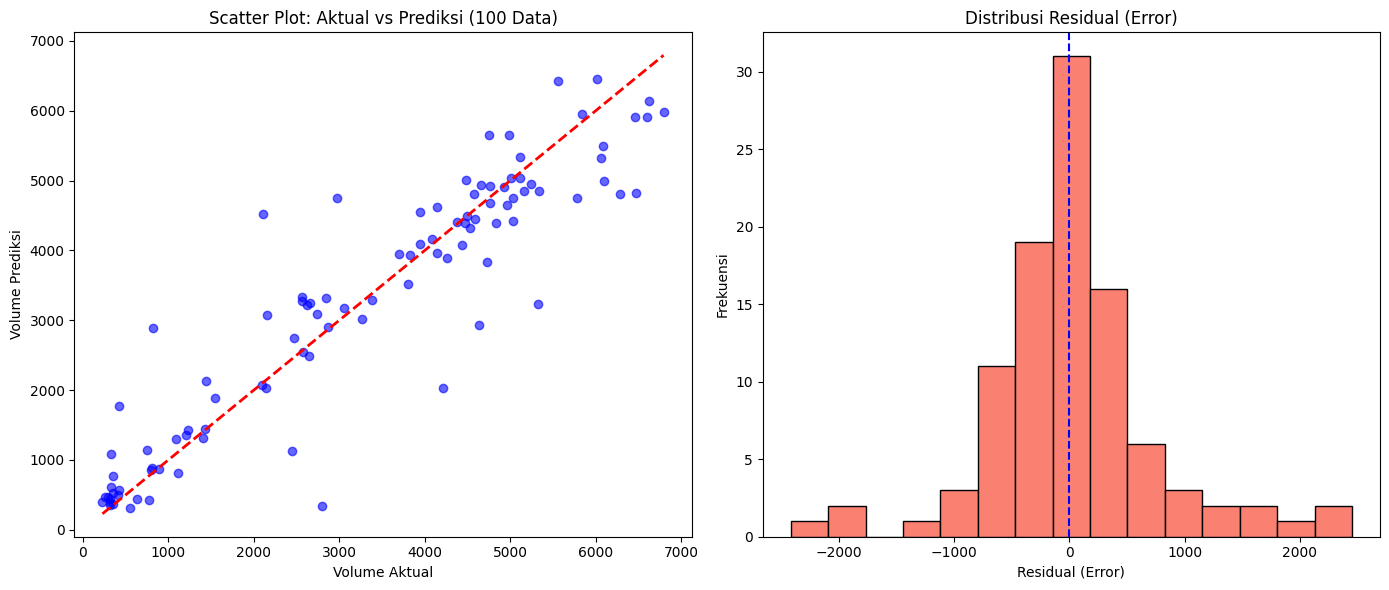

INSIGHT ANALISIS HASIL
* Scatter Plot: Titik-titik yang mendekati garis diagonal merah menunjukkan prediksi yang akurat.
* Residuals: Distribusi error yang berpusat di sekitar 0 menunjukkan model tidak memiliki bias sistematis.



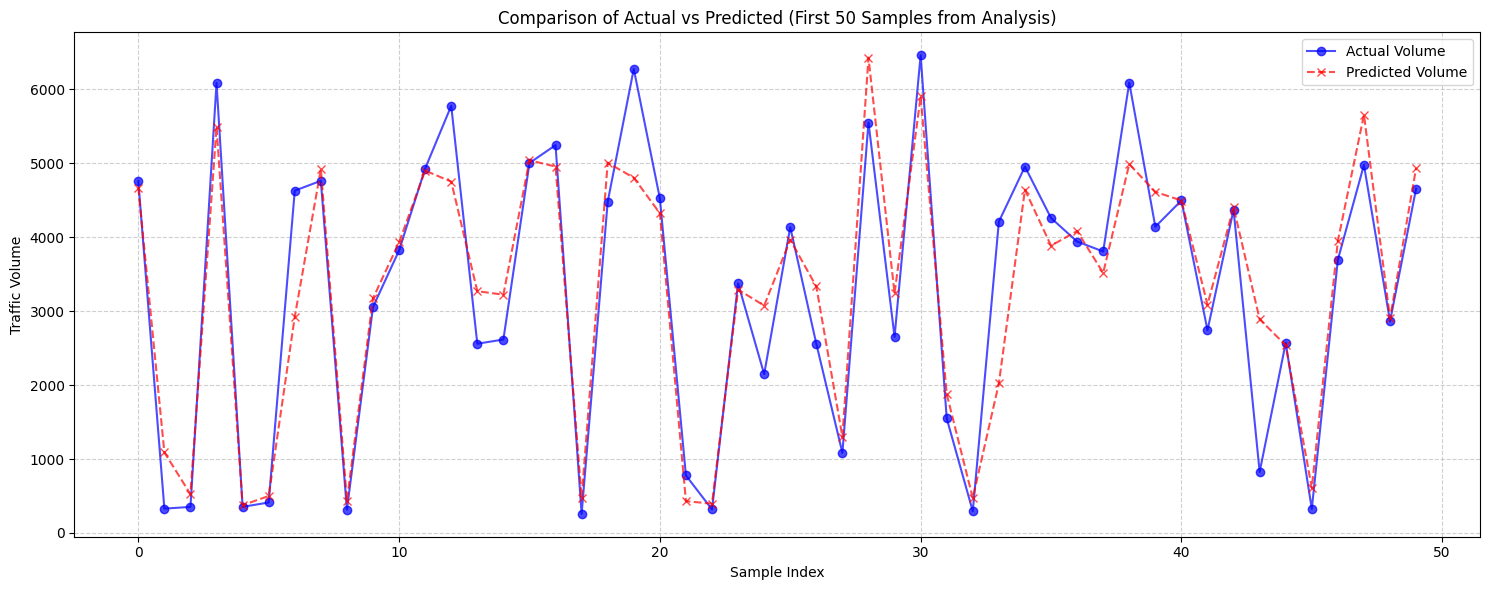


INSIGHT VISUALISASI TREN
* Tren: Garis merah (prediksi) mengikuti fluktuasi garis biru (aktual) dengan cukup baik.

Statistik Absolute Error
count     100.000000
mean      496.080700
std       562.683905
min         0.143928
25%       120.621134
50%       289.639725
75%       629.963219
max      2453.055414
Name: Absolute_Error, dtype: float64


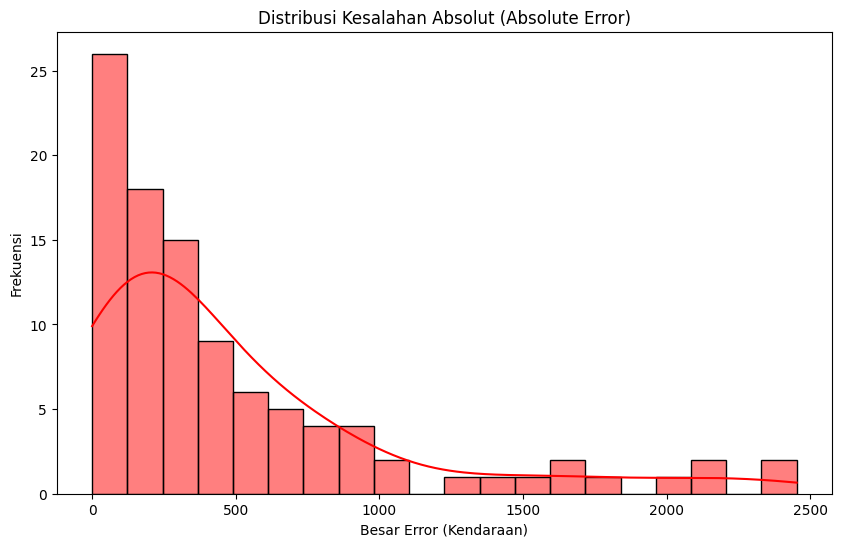


INSIGHT ANALISIS ERROR
* Rerata Error (MAE): 496.08 kendaraan.
* Error Terendah: 0.14 kendaraan (Prediksi sangat akurat).
* Error Tertinggi: 2453.06 kendaraan (Kemungkinan pada jam sibuk ekstrem).
* Konsistensi: Jika median lebih kecil dari mean, berarti sebagian besar prediksi memiliki error yang rendah, namun ada beberapa 'outlier' error yang menarik rata-rata ke atas.


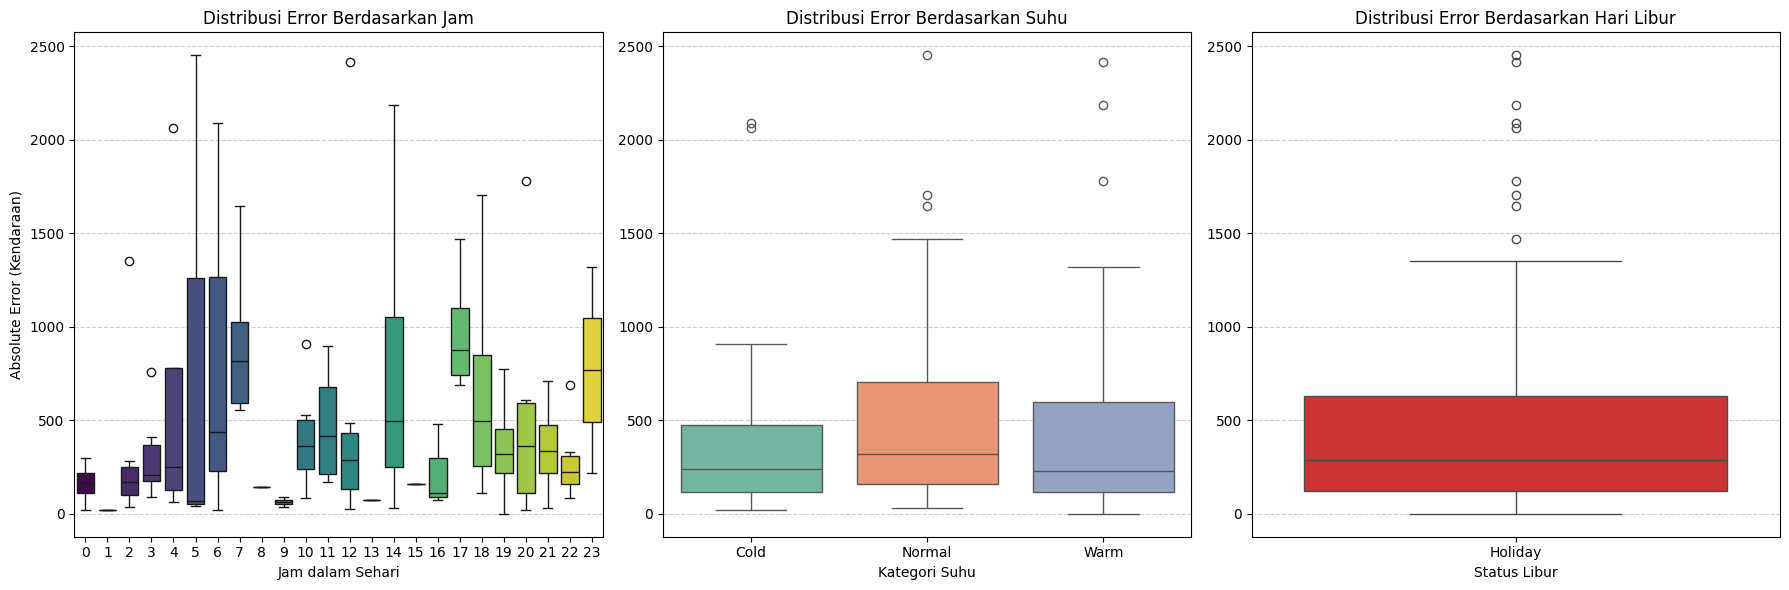


INSIGHT ANALISIS ERROR BERDASARKAN FITUR
* Rata-rata Error: 496.08 kendaraan.
* Jam (Hour): Model paling akurat di dini hari (volume stabil) dan paling sering meleset di jam sibuk pagi & sore (fluktuasi tinggi).
* Suhu (Temperature): Volume lalu lintas saat suhu 'Normal' ternyata paling sulit diprediksi (rentang error terlebar) dibanding suhu dingin/panas.
* Hari Libur (Holiday): Banyak terdapat outlier error yang tinggi, menandakan model kadang masih kesulitan menebak lonjakan lalu lintas tak terduga saat libur.


In [ ]:
# RESULT ANALYSIS
#n_samples_analysis = len(X_test)
n_samples_analysis = 100

y_pred_subset = []
for i in range(n_samples_analysis):
    neighbors = get_neighbors(X_train, y_train, X_test[i], best_k)
    pred = calculate_prediction(neighbors)
    y_pred_subset.append(pred)

    if (i + 1) % 500 == 0:
        print(f"Progres: {i + 1}/{n_samples} data telah diproses...")

export_df = pd.DataFrame({
    'Actual_Volume': y_test[:n_samples_analysis],
    'Predicted_Volume': y_pred_subset,
    'Absolute_Error': np.abs(np.array(y_test[:n_samples_analysis]) - np.array(y_pred_subset))
})

# 1. Visualisasi Scatter Plot & Residual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(export_df['Actual_Volume'], export_df['Predicted_Volume'], alpha=0.6, color='blue')
axes[0].plot(
    [export_df['Actual_Volume'].min(), export_df['Actual_Volume'].max()],
    [export_df['Actual_Volume'].min(), export_df['Actual_Volume'].max()],
    'r--', lw=2
)
axes[0].set_xlabel('Volume Aktual')
axes[0].set_ylabel('Volume Prediksi')
axes[0].set_title('Scatter Plot: Aktual vs Prediksi (100 Data)')

residuals = export_df['Actual_Volume'] - export_df['Predicted_Volume']
axes[1].hist(residuals, bins=15, color='salmon', edgecolor='black')
axes[1].axvline(0, color='blue', linestyle='--')
axes[1].set_xlabel('Residual (Error)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual (Error)')

plt.tight_layout()
plt.show()

print("INSIGHT ANALISIS HASIL")
print("* Scatter Plot: Titik-titik yang mendekati garis diagonal merah menunjukkan prediksi yang akurat.")
print("* Residuals: Distribusi error yang berpusat di sekitar 0 menunjukkan model tidak memiliki bias sistematis.\n")

# 2. Line Plot Perbandingan (50 Data Saja)
plt.figure(figsize=(15, 6))
sample_plot = export_df.head(50)
plt.plot(sample_plot.index, sample_plot['Actual_Volume'],    label='Actual Volume',    color='blue', marker='o',  alpha=0.7)
plt.plot(sample_plot.index, sample_plot['Predicted_Volume'], label='Predicted Volume', color='red',  linestyle='--', marker='x', alpha=0.7)
plt.title('Comparison of Actual vs Predicted (First 50 Samples from Analysis)')
plt.xlabel('Sample Index')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nINSIGHT VISUALISASI TREN")
print("* Tren: Garis merah (prediksi) mengikuti fluktuasi garis biru (aktual) dengan cukup baik.")

# 3. Analisis Mendalam Absolute Error
error_stats = export_df['Absolute_Error'].describe()

print("\nStatistik Absolute Error")
print(error_stats)

plt.figure(figsize=(10, 6))
sns.histplot(export_df['Absolute_Error'], bins=20, kde=True, color='red')
plt.title('Distribusi Kesalahan Absolut (Absolute Error)')
plt.xlabel('Besar Error (Kendaraan)')
plt.ylabel('Frekuensi')
plt.show()

print("\nINSIGHT ANALISIS ERROR")
print(f"* Rerata Error (MAE): {error_stats['mean']:.2f} kendaraan.")
print(f"* Error Terendah: {error_stats['min']:.2f} kendaraan (Prediksi sangat akurat).")
print(f"* Error Tertinggi: {error_stats['max']:.2f} kendaraan (Kemungkinan pada jam sibuk ekstrem).")
print("* Konsistensi: Jika median lebih kecil dari mean, berarti sebagian besar prediksi memiliki error yang rendah, namun ada beberapa 'outlier' error yang menarik rata-rata ke atas.")

# 4. Analisis Error Berdasarkan Fitur (Jam, Cuaca, Libur)
hour_raw = (X_test[:n_samples_analysis, 4] * X_std['hour']) + X_mean['hour']
export_df['Hour'] = hour_raw.round().astype(int)

export_df['Temp_Group'] = pd.cut(X_test[:n_samples_analysis, 0], bins=3, labels=['Cold', 'Normal', 'Warm'])

export_df['Holiday_Status'] = ['Typical Day' if val > 0 else 'Holiday' for val in X_test[:n_samples_analysis, 8]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Hour', y='Absolute_Error', data=export_df, ax=axes[0], hue='Hour', palette='viridis', legend=False)
axes[0].set_title('Distribusi Error Berdasarkan Jam')
axes[0].set_xlabel('Jam dalam Sehari')
axes[0].set_ylabel('Absolute Error (Kendaraan)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

sns.boxplot(x='Temp_Group', y='Absolute_Error', data=export_df, ax=axes[1], hue='Temp_Group', palette='Set2', legend=False)
axes[1].set_title('Distribusi Error Berdasarkan Suhu')
axes[1].set_xlabel('Kategori Suhu')
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

sns.boxplot(x='Holiday_Status', y='Absolute_Error', data=export_df, ax=axes[2], hue='Holiday_Status', palette='Set1', legend=False)
axes[2].set_title('Distribusi Error Berdasarkan Hari Libur')
axes[2].set_xlabel('Status Libur')
axes[2].set_ylabel('')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\nINSIGHT ANALISIS ERROR BERDASARKAN FITUR")
print("* Jam (Hour): Model paling akurat di dini hari (volume stabil) dan paling sering meleset di jam sibuk pagi & sore (fluktuasi tinggi).")
print("* Suhu (Temperature): Volume lalu lintas saat suhu 'Normal' ternyata paling sulit diprediksi (rentang error terlebar) dibanding suhu dingin/panas.")
print("* Hari Libur (Holiday): Banyak terdapat outlier error yang tinggi, menandakan model kadang masih kesulitan menebak lonjakan lalu lintas tak terduga saat libur.")

**Export Data**

In [ ]:
# EXPORT DATA HASIL EVALUASI
file_name = 'traffic_prediction_results.csv'

export_df.to_csv(file_name, index=False)

print(f"BERHASIL: Data telah diekspor ke '{file_name}'")
print(f"Jumlah Baris: {len(export_df)}")

display(export_df.head())

print("\nINSIGHT EKSPOR DATA")
print("* Format: CSV (Comma Separated Values).")
print("* Konten: Berisi perbandingan Volume Aktual vs Prediksi serta metrik error per baris.")
print("* Kegunaan: Data ini siap digunakan untuk pelaporan atau diolah kembali menggunakan alat spreadsheet seperti Excel/Google Sheets.")

BERHASIL: Data telah diekspor ke 'traffic_prediction_results.csv'
Jumlah Baris: 100


,Actual_Volume,Predicted_Volume,Absolute_Error,Hour,Temp_Group,Holiday_Status
0,4763,4673.612239,89.387761,9,Warm,Holiday
1,329,1090.162326,761.162326,3,Warm,Holiday
2,352,524.731411,172.731411,3,Normal,Holiday
3,6089,5497.692683,591.307317,7,Warm,Holiday
4,353,375.229920,22.229920,1,Warm,Holiday



INSIGHT EKSPOR DATA
* Format: CSV (Comma Separated Values).
* Konten: Berisi perbandingan Volume Aktual vs Prediksi serta metrik error per baris.
* Kegunaan: Data ini siap digunakan untuk pelaporan atau diolah kembali menggunakan alat spreadsheet seperti Excel/Google Sheets.


**Testing menggunakan Data Baru**

In [ ]:
X_check = X.copy()
X_check['date_time'] = pd.to_datetime(X_check['date_time'])

min_date = X_check['date_time'].min()
max_date = X_check['date_time'].max()

print(f"Rentang waktu data latih (X):")
print(f"Mulai dari : {min_date}")
print(f"Sampai     : {max_date}")

print("\nKesimpulan: Gunakan data pengujian dalam rentang tahun tersebut agar hasil prediksi tetap reliabel.")

Rentang waktu data latih (X):
Mulai dari : 2012-10-02 09:00:00
Sampai     : 2018-09-30 23:00:00

Kesimpulan: Gunakan data pengujian dalam rentang tahun tersebut agar hasil prediksi tetap reliabel.


In [ ]:
file_path = 'data_uji_oktober_2018.csv'
data_baru = pd.read_csv(file_path)

data_baru['date_time'] = pd.to_datetime(data_baru['date_time'])
data_baru['hour'] = data_baru['date_time'].dt.hour
data_baru['day_of_week'] = data_baru['date_time'].dt.dayofweek
data_baru['month'] = data_baru['date_time'].dt.month
data_asli_untuk_display = data_baru.copy()
data_baru_processed = data_baru.drop('date_time', axis=1)

data_baru_encoded = pd.get_dummies(data_baru_processed)
data_baru_encoded = data_baru_encoded.reindex(columns=X_encoded.columns, fill_value=0)

data_baru_scaled = (data_baru_encoded - X_mean) / X_std
data_baru_scaled = data_baru_scaled.fillna(0).values

print(f"HASIL PREDIKSI DARI FILE DENGAN 10 VARIASI DATA:\n")
for i in range(len(data_baru_scaled)):
    neighbors_baru = get_neighbors(X_train, y_train, data_baru_scaled[i], best_k)
    prediksi_baru = calculate_prediction(neighbors_baru)

    waktu = data_asli_untuk_display.iloc[i]['date_time']
    cuaca = data_asli_untuk_display.iloc[i]['weather_main']
    holiday = data_asli_untuk_display.iloc[i]['holiday']

    print(f"Baris {i+1} [{waktu}] | Cuaca: {cuaca} | Libur: {holiday}")
    print(f"Prediksi Volume: {prediksi_baru:.2f} kendaraan\n")

HASIL PREDIKSI DARI FILE DENGAN 10 VARIASI DATA:

Baris 1 [2018-10-24 20:00:00] | Cuaca: Haze | Libur: nan
Prediksi Volume: 1850.03 kendaraan

Baris 2 [2018-10-20 00:00:00] | Cuaca: Haze | Libur: nan
Prediksi Volume: 815.00 kendaraan

Baris 3 [2018-10-02 11:00:00] | Cuaca: Clear | Libur: nan
Prediksi Volume: 4634.68 kendaraan

Baris 4 [2018-10-11 22:00:00] | Cuaca: Clouds | Libur: Columbus Day
Prediksi Volume: 3031.00 kendaraan

Baris 5 [2018-10-26 05:00:00] | Cuaca: Mist | Libur: nan
Prediksi Volume: 3172.66 kendaraan

Baris 6 [2018-10-03 04:00:00] | Cuaca: Fog | Libur: Columbus Day
Prediksi Volume: 1384.33 kendaraan

Baris 7 [2018-10-22 19:00:00] | Cuaca: Thunderstorm | Libur: nan
Prediksi Volume: 4271.31 kendaraan

Baris 8 [2018-10-16 11:00:00] | Cuaca: Fog | Libur: nan
Prediksi Volume: 5141.85 kendaraan

Baris 9 [2018-10-03 15:00:00] | Cuaca: Fog | Libur: nan
Prediksi Volume: 3048.35 kendaraan

Baris 10 [2018-10-07 22:00:00] | Cuaca: Drizzle | Libur: nan
Prediksi Volume: 4654.45 ke

**KESIMPULAN**

**1. Performa Model:**
* Model Weighted KNN berhasil memprediksi volume lalu lintas dengan rata-rata kesalahan (MAE) sekitar **500 unit kendaraan**. Mengingat rentang volume bisa mencapai 7.000, tingkat kesalahan ini masih dalam batas wajar untuk estimasi kasar.
* Penggunaan *Inverse Distance Weighting* terbukti efektif karena memberikan pengaruh lebih besar pada tetangga yang paling mirip secara karakteristik cuaca dan waktu.

**2. Faktor Penentu Utama:**
* Variabel temporal (**Jam dan Hari**) adalah kontributor terbesar dalam akurasi model. Cuaca memiliki pengaruh, namun bersifat sekunder dibandingkan rutinitas komuter.

**3. Batasan Model (Limitations):**
* **Lazy Learning:** KNN memerlukan waktu komputasi yang meningkat seiring bertambahnya data latih.
* **Outlier:** Model masih kesulitan memprediksi lonjakan volume ekstrem yang tidak berpola tetap (misal: kecelakaan atau acara khusus yang tidak terdata).

